# CRISPR knockouts

A CRISPR screen asks what a gene does by removing it. Genes whose products work together, such as the subunits
of one protein complex, should give the same phenotype when knocked out. A good morphological map therefore
recovers known complexes, and it places a gene of unknown function next to its partners.

This page uses the CRISPR arm of JUMP {cite:p}`Chandrasekaran_2023`: U2OS cells, each well targeting one gene.
{func}`~mantispy.ds.jump_crispr` returns the profiles as the consortium assembled them, corrected for well
position and cell count, normalized and feature-selected. It joins the gene each well targets, which wells are
controls, and the chromosome arm each gene sits on.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import mantispy as mt

wells = mt.ds.jump_crispr()
obs = wells.obs
is_trt = obs["Metadata_Control_Type"] == "trt"
treated = obs[is_trt]
{
    "wells": wells.n_obs,
    "features": wells.n_vars,
    "plates": obs["Metadata_Plate"].nunique(),
    "genes": treated["Metadata_Perturbation"].nunique(),
    "median wells per gene": int(treated.groupby("Metadata_Perturbation", observed=True).size().median()),
    "control wells": obs.loc[~is_trt, "Metadata_Perturbation"].astype(str).value_counts().to_dict(),
}

{'wells': 51185,
 'features': 595,
 'plates': 148,
 'genes': 7974,
 'median wells per gene': 5,
 'control wells': {'no-guide': 4724, 'non-targeting': 2754, 'PLK1': 569}}

About 8,000 genes, five wells each, over 148 plates. The negative controls are wells with no guide and wells
whose guide targets nothing in the genome. The positive control is PLK1, a kinase cells need to divide.

The consortium's CRISPR recipe continues from these profiles by sphering against the negative controls. Unlike
BBBC021 on [Plate artifacts and corrections](../profiles/artifacts.ipynb), there are far more control wells than
features here, 7,478 against 595, so the control covariance is well determined. A copy is kept as published,
for a comparison further down. `modz` weights each well by how well it agrees with the gene's other wells, which
suits five noisy replicates.

In [2]:
def per_gene(profiles):
    """One modz signature per targeted gene, leaving out the controls."""
    signatures = mt.tl.consensus(profiles, method="modz")
    return signatures[signatures.obs["Metadata_Control_Type"].astype(str) == "trt"].copy()


published = per_gene(wells)
mt.pp.sphere(wells, reference="negcon")

## Do the two negative controls agree?

The negative controls come in two kinds: 4,724 empty wells (`no-guide`) and 2,754 wells carrying a guide that
matches nothing in the genome (`non-targeting`). The sphering above pooled both as its reference, taking the two
for one inert baseline. A non-targeting guide cuts nothing, so it carries no Cas9 cutting toxicity: the
double-strand-break burden and the TP53-dependent DNA-damage response that arise at real cut sites are a separate,
well-documented confounder ({cite:p}`Morgens_2017`; {cite:p}`Alvarez_2022`), one controlled with
dedicated safe-targeting guides, which this screen's control pool does not include. What a non-targeting guide
does carry is the burden of delivery and expression: the lentiviral integration, the sgRNA and the Cas9 that the
empty wells never received. Comparing `no-guide` against `non-targeting` therefore isolates that
delivery-and-expression load, not cutting. The field usually treats non-targeting guides as the working baseline
and normalizes to them, so checking that they behave like empty wells is a standard QC step. If they do not,
`non-targeting` is not quite empty, and which wells define the reference matters.

We test it with a retrieval question on the sphered negcon wells, where plate effects are already gone: does a
control well retrieve others of its own kind — `no-guide` or `non-targeting` — beyond chance? `pos_sameby` makes a
positive pair two wells of one kind and `neg_diffby` makes a negative pair two wells of different kinds, with
`reference=None` so no wells are held out. An mAP near chance means the two kinds are one baseline; an mAP above
chance means they separate. `null_size` can stay modest, as there are only two groups to score.

In [3]:
negcon = wells[wells.obs["Metadata_Control_Type"].astype(str) == "negcon"].copy()
mt.tl.map(
    negcon,
    pos_sameby=["Metadata_Perturbation"],
    neg_diffby=["Metadata_Perturbation"],
    reference=None,
    null_size=20_000,
    key_added="negcon_agreement",
)
negcon.uns["mantispy"]["negcon_agreement"].round(3)

,Metadata_Perturbation,mean_average_precision,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p
0,no-guide,0.639,0.019,0.105,0.105,False,False
1,non-targeting,0.383,0.023,0.006,0.011,True,True


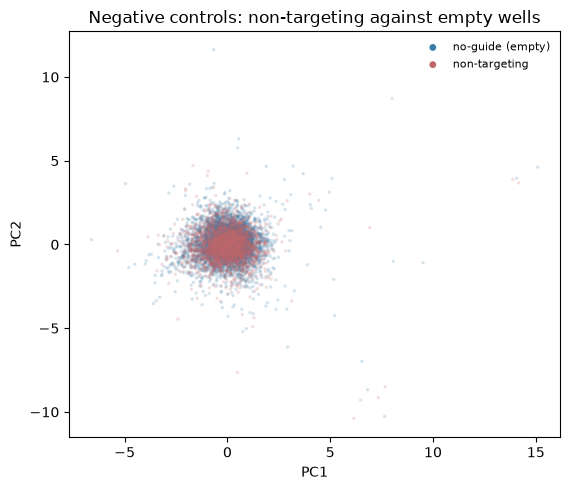

In [4]:
feats = np.asarray(negcon.X, dtype=np.float64)
feats -= feats.mean(axis=0)
scale = feats.std(axis=0)
feats /= np.where(scale > 0, scale, 1.0)
u, s, _ = np.linalg.svd(feats, full_matrices=False)
coords = u[:, :2] * s[:2]
is_non_targeting = (negcon.obs["Metadata_Perturbation"].astype(str) == "non-targeting").to_numpy()

fig, ax = plt.subplots(figsize=(5.8, 5))
ax.scatter(
    coords[~is_non_targeting, 0],
    coords[~is_non_targeting, 1],
    s=6,
    alpha=0.2,
    color="#3a7ca5",
    edgecolor="none",
    label="no-guide (empty)",
)
ax.scatter(
    coords[is_non_targeting, 0],
    coords[is_non_targeting, 1],
    s=6,
    alpha=0.2,
    color="#c1666b",
    edgecolor="none",
    label="non-targeting",
)
ax.set(xlabel="PC1", ylabel="PC2", title="Negative controls: non-targeting against empty wells")
legend = ax.legend(frameon=False, fontsize=8, markerscale=2)
for handle in legend.legend_handles:
    handle.set_alpha(1)
fig.tight_layout()
plt.show()

The table gives an mAP per control kind and a p-value for whether each kind retrieves its own beyond chance; the figure shows the same as two point clouds.

The non-targeting wells are told apart from the empty ones beyond chance: their mAP of 0.383 carries a corrected p-value of 0.011, while the no-guide row's higher mAP of 0.639 does not reach significance (p 0.105) — a reminder that an mAP is read against its permutation null, not on its face. So the two negative controls are not one inert baseline. What separates non-targeting from empty is the burden of delivery and expression — the lentiviral integration, the sgRNA and the Cas9 the empty wells never received — not a cut, since a non-targeting guide cuts nothing. Because the sphering above pools both kinds as `negcon`, every knockout is scored against a reference that carries this delivery signature, and the choice of reference — empty wells, non-targeting, or both — moves the map. Worth checking, rather than assuming the two agree, before leaning on one baseline.

## How do they differ?

The two negative controls are distinguishable, so the next question is what the difference is made of: which
measurements carry it? On the same sphered negcon wells, where the plate effects are already gone,
{func}`~mantispy.tl.effect_size` gives the per-feature effect of the non-targeting wells against the empty
ones, with `no-guide` as the reference so a positive effect marks a feature the non-targeting wells sit
*above*. `cohens_d` is a standardized mean difference per feature, so the features are comparable and the
check stays cheap, with no permutation null unlike the mAP above. The twelve features with the largest
absolute effect are the delivery-and-expression signature the two controls differ by.

In [5]:
# The sphered negcon wells from the agreement check, with no-guide as the reference, so each feature's effect
# reads as non-targeting minus empty; cohens_d is a standardized mean difference, comparable across features.
negcon.obs["_no_guide"] = (negcon.obs["Metadata_Perturbation"].astype(str) == "no-guide").to_numpy()
mt.tl.effect_size(
    negcon,
    groupby="Metadata_Perturbation",
    reference="_no_guide",
    method="cohens_d",
    pvalues=False,
    key_added="delivery",
)
# The non-targeting group carries the contrast; the reference is scored against itself as a near-zero check.
delivery = negcon.uns["mantispy"]["delivery"]
delivery = delivery[delivery["group"] == "non-targeting"].copy()
delivery["effect"].abs().describe().round(3)

count    595.000
mean       0.043
std        0.040
min        0.000
25%        0.014
50%        0.031
75%        0.059
max        0.246
Name: effect, dtype: float64

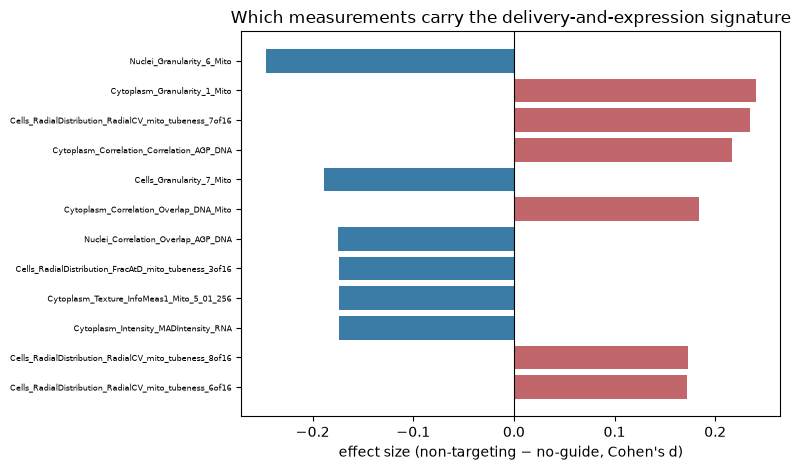

In [6]:
# The twelve features that separate non-targeting from empty most, coloured by the sign of the effect.
strongest = delivery.reindex(delivery["effect"].abs().sort_values(ascending=False).index).head(12)[::-1]
colours = np.where(strongest["effect"] >= 0, "#c1666b", "#3a7ca5")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(range(len(strongest)), strongest["effect"], color=colours)
ax.set_yticks(range(len(strongest)), strongest["feature"], fontsize=6)
ax.axvline(0, color="black", lw=0.8)
ax.set(
    xlabel="effect size (non-targeting − no-guide, Cohen's d)",
    title="Which measurements carry the delivery-and-expression signature",
)
fig.tight_layout()
plt.show()

The bar names the measurements that carry the difference: `Nuclei_Granularity_6_Mito`, `Cytoplasm_Granularity_1_Mito`, the radial distribution of mitochondrial tubeness across the cell, a `Cytoplasm_Correlation_AGP_DNA` term and a handful of Mito texture and DNA–Mito overlap features. By kind they are granularity, radial-distribution and texture features, sitting mostly in the mitochondrial (Mito) channel, with a little RNA intensity. Whatever the exact list, the signature is one of delivery and expression, not cutting: the non-targeting wells carry a lentiviral integration, an sgRNA and Cas9 that the empty wells never received, and that added burden tilts their staining and morphology — a metabolic, mitochondrial lean is what one would expect from it — while a non-targeting guide makes no cut to leave a sharp local mark. The effects are modest in size: a median absolute Cohen's d of 0.03, reaching 0.25 at the top. The two controls are distinguishable, as the retrieval test above found, but only modestly, so this is a lean of the baseline rather than a phenotype of its own — though modest is not nothing when these wells define the reference every knockout is scored against.

## Does the reference you normalize to change the hits?

The two negative controls are not one baseline, so the reference the screen normalizes against is a choice, not a
formality. Does that choice reach the hits? A cheap check answers it without the 200,000-permutation mAP above.
Start from a fresh load, so the already-sphered `wells` is left alone, and normalize it four ways: to the empty
wells alone, to the non-targeting wells alone, to both together (`negcon`), and to every well on the plate. Each
is a per-plate robust MAD normalization; they differ only in which rows set the centre and spread. A gene's
activity is then read cheaply as the L2 norm of its modz consensus — its distance from the reference-centred
origin — with no permutations. If the reference barely matters, a gene keeps its activity whichever rows define
zero.

In [7]:
raw = mt.ds.jump_crispr()
pert = raw.obs["Metadata_Perturbation"].astype(str)
# Boolean flags picking out each negcon subset; "negcon" already selects both, None every well.
raw.obs["_ref_no_guide"] = (pert == "no-guide").to_numpy()
raw.obs["_ref_non_targeting"] = (pert == "non-targeting").to_numpy()
references = {
    "no-guide only": "_ref_no_guide",
    "non-targeting only": "_ref_non_targeting",
    "both (negcon)": "negcon",
    "whole-plate": None,
}

# Per-plate robust-normalize a fresh copy to each reference, noting features left degenerate under any choice.
normalized = {}
degenerate = np.zeros(raw.n_vars, dtype=bool)
for name, reference in references.items():
    norm = mt.pp.normalize(raw, method="mad_robustize", by="Metadata_Plate", reference=reference, copy=True)
    degenerate |= norm.var["degenerate_scale"].to_numpy()
    normalized[name] = norm

# Activity per gene: the L2 norm of its modz consensus, its distance from the reference-centred origin,
# over the features usable under every reference so the four scores are comparable.
keep = ~degenerate
activity_columns = {}
for name, norm in normalized.items():
    signatures = per_gene(norm[:, keep])
    activity_columns[name] = pd.Series(
        np.linalg.norm(np.asarray(signatures.X, dtype=np.float64), axis=1),
        index=signatures.obs["Metadata_Perturbation"].astype(str),
    )
activity = pd.DataFrame(activity_columns).dropna()
activity.shape

(7971, 4)

In [8]:
top = 100


def _jaccard(a, b):
    """Overlap of two gene sets, as intersection over union."""
    sa, sb = set(a), set(b)
    return len(sa & sb) / len(sa | sb)


pairs = [
    ("no-guide only", "non-targeting only"),
    ("both (negcon)", "whole-plate"),
    ("no-guide only", "whole-plate"),
]
sensitivity = pd.DataFrame(
    {
        "Spearman r": [float(spearmanr(activity[a], activity[b]).statistic) for a, b in pairs],
        f"top-{top} Jaccard": [
            _jaccard(activity[a].nlargest(top).index, activity[b].nlargest(top).index) for a, b in pairs
        ],
    },
    index=[f"{a}  vs  {b}" for a, b in pairs],
).round(3)
sensitivity

,Spearman r,top-100 Jaccard
no-guide only vs non-targeting only,0.781,0.724
both (negcon) vs whole-plate,0.658,0.695
no-guide only vs whole-plate,0.432,0.613


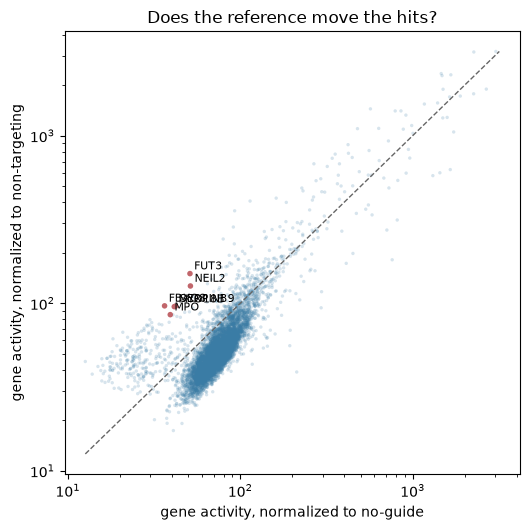

In [9]:
x, y = activity["no-guide only"], activity["non-targeting only"]
movers = (x.rank() - y.rank()).abs().nlargest(6).index

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.scatter(x, y, s=6, alpha=0.2, color="#3a7ca5", edgecolor="none")
lo = float(min(x[x > 0].min(), y[y > 0].min()))
hi = float(max(x.max(), y.max()))
ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color="0.4")
ax.set_xscale("log")
ax.set_yscale("log")
ax.scatter(x[movers], y[movers], s=16, color="#c1666b", edgecolor="none")
for gene in movers:
    ax.annotate(gene, (x[gene], y[gene]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set(
    xlabel="gene activity, normalized to no-guide",
    ylabel="gene activity, normalized to non-targeting",
    title="Does the reference move the hits?",
)
fig.tight_layout()
plt.show()

The table reads the reference off the ranking directly. Between the two negative controls the gene activities correlate at Spearman r = 0.78, and their top 100 genes by activity overlap by 72% (Jaccard). The scatter shows the same pair gene by gene: points on the dashed diagonal keep their activity whichever baseline defines zero, and the spread away from it is what the reference moves; the labelled genes shift rank the most.

Read against the diagonal, the choice of reference **moves** the hits. Even the two negative-control baselines — empty and non-targeting — agree only at r = 0.78 and share 72% of their top 100, so more than a quarter of the strongest hits turn on which controls define zero. Whole-plate normalization, which depends on no control at all, diverges further still: r = 0.43 against the empty baseline and r = 0.66 against the pooled `negcon`. The reference is a first-order analytic decision, not a formality.

## What to do about it

- **Prefer whole-plate normalization.** When perturbations are spread evenly across plates, as they are in this
  screen, per-plate robust normalization over *all* wells is the field's primary recommendation, and it sidesteps
  the negcon-choice problem entirely: no subset of wells defines zero, so there is no baseline to pick wrong. This
  is the JUMP recipe {cite:p}`Chandrasekaran_2023`, in line with the Carpenter–Singh lab's normalization guidance.
- **Normalize to controls only when the layout forces it.** Reach for control-based normalization when the plate
  layout is uneven, or when many wells are expected to be active and would pull a whole-plate centre off zero — and
  only where there are enough control wells (at least 16, more is better) that are not confined to a single row or
  column.
- **When you do, prefer non-targeting over empty wells.** Non-targeting guides are delivery-matched: a knockout is
  then judged against wells that also received a guide, a lentiviral integration and Cas9, rather than against
  empty wells that received none. But, as the section above showed, non-targeting is not identical to empty, so
  state which baseline you used.
- **Cutting toxicity needs safe-targeting guides.** The gold standard for separating Cas9 *cutting* toxicity from
  the biology is safe-targeting guides, which cut at non-genic loci and so carry the double-strand-break burden
  without knocking out a gene ({cite:p}`Morgens_2017`; {cite:p}`Alvarez_2022`). This screen's control pool has
  none, so cutting toxicity cannot be isolated here — the empty-versus-non-targeting contrast measures delivery and
  expression, not the cut.

For this notebook the sphering above used both negative controls pooled; the whole-plate route is the cleaner
default, and the comparison here shows how far the two diverge on these data.

## Which knockouts have a phenotype?

Two questions, both answered with mAP. Does a gene's knockout stand apart from the negative controls on its own
plates (`mode="activity"`)? And do its wells find each other among all the other knockouts
(`mode="replicability"`)?

With nearly 8,000 genes the permutation null has to be large. `tl.map` cannot return a p-value below one over
the number of draws plus one, and a correction over nearly 8,000 groups at 5% needs about 160,000 draws before a
single gene can be called on its own.

In [10]:
genes_screened = set(treated["Metadata_Perturbation"].astype(str))
rows = {}
for mode in ("activity", "replicability"):
    mt.tl.map(wells, mode=mode, null_size=200_000, key_added=mode)
    table = wells.uns["mantispy"][mode]
    table = table[table["Metadata_Perturbation"].astype(str).isin(genes_screened)]
    rows[mode] = {
        "genes scored": len(table),
        "called at q < 0.05": int(table["below_corrected_p"].sum()),
        "mean mAP": round(float(table["mean_average_precision"].mean()), 3),
    }
pd.DataFrame(rows).T

,genes scored,called at q < 0.05,mean mAP
activity,7971.0,4715.0,0.553
replicability,7971.0,1175.0,0.107


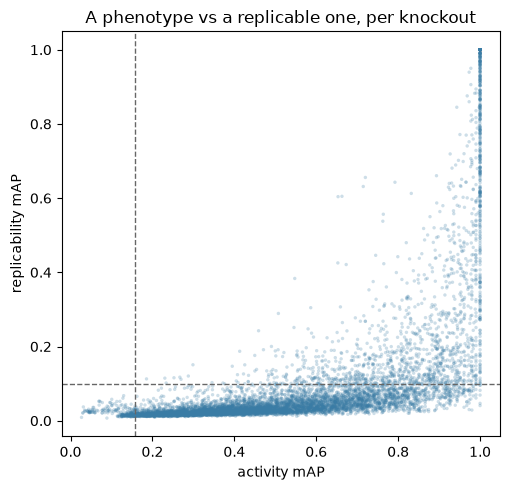

In [11]:
activity_tab = wells.uns["mantispy"]["activity"].set_index("Metadata_Perturbation")
repl_tab = wells.uns["mantispy"]["replicability"].set_index("Metadata_Perturbation")
screened = sorted(genes_screened & set(activity_tab.index) & set(repl_tab.index))
phenotype = (
    pd.DataFrame(
        {
            "activity": activity_tab["mean_average_precision"],
            "replicability": repl_tab["mean_average_precision"],
            "activity_called": activity_tab["below_corrected_p"],
            "replicability_called": repl_tab["below_corrected_p"],
        }
    )
    .loc[screened]
    .dropna()
)
# The mAP a gene needs to clear q < 0.05, read off the genes called on each axis.
activity_cut = phenotype.loc[phenotype["activity_called"], "activity"].min()
repl_cut = phenotype.loc[phenotype["replicability_called"], "replicability"].min()

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(phenotype["activity"], phenotype["replicability"], s=6, alpha=0.25, color="#3a7ca5", edgecolor="none")
ax.axvline(activity_cut, ls="--", lw=1, color="0.4")
ax.axhline(repl_cut, ls="--", lw=1, color="0.4")
ax.set(xlabel="activity mAP", ylabel="replicability mAP", title="A phenotype vs a replicable one, per knockout")
fig.tight_layout()
plt.show()

4,715 of 7,971 knockouts stand apart from the controls, but only 1,175 are told apart from the other knockouts
by their own wells. Many genes have a phenotype, and fewer have one that sets them apart from other knockouts.

In [12]:
genes = per_gene(wells)
genes.shape

(7971, 595)

## Do subunits of one complex look alike?

{func}`~mantispy.ds.corum` returns the human protein complexes of CORUM, as the benchmark of
{cite:t}`Celik_2024` distributes them. Two genes of one complex count as a related pair, and
{func}`~mantispy.metrics.known_relationships` asks how many related pairs land in either tail of the map's
similarity distribution. `n_permutations` measures chance on this map by shuffling which gene each annotation
row names.

In [13]:
complexes = mt.ds.corum()
rows = []
for percentile in (1.0, 5.0, 10.0):
    result = mt.metrics.known_relationships(genes, complexes, percentile=percentile, n_permutations=100).iloc[0]
    rows.append(
        {
            "tail width (%)": percentile,
            "shuffled annotation": float(result["null"]),
            "observed": float(result["value"]),
            "p": float(result["p_value"]),
        }
    )
pd.DataFrame(rows).round(3)

,tail width (%),shuffled annotation,observed,p
0,1.0,0.038,0.133,0.01
1,5.0,0.143,0.259,0.01
2,10.0,0.253,0.371,0.01


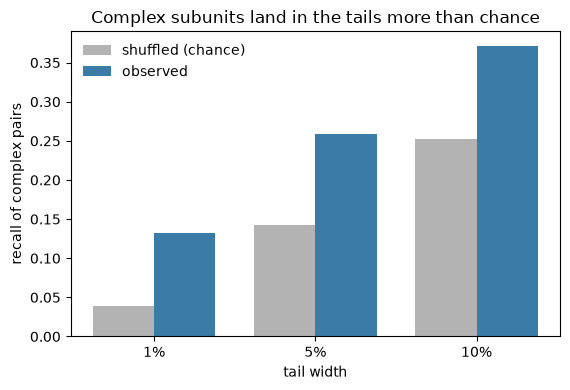

In [14]:
recall = pd.DataFrame(rows)
x = np.arange(len(recall))
width = 0.38
fig, ax = plt.subplots(figsize=(5.8, 4))
ax.bar(x - width / 2, recall["shuffled annotation"], width, label="shuffled (chance)", color="0.7")
ax.bar(x + width / 2, recall["observed"], width, label="observed", color="#3a7ca5")
ax.set_xticks(x, [f"{p:g}%" for p in recall["tail width (%)"]])
ax.set(
    xlabel="tail width", ylabel="recall of complex pairs", title="Complex subunits land in the tails more than chance"
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

At every tail width, pairs from one complex land in the tails more often than chance on this map, 13% against
4% at the strictest, and no shuffle reaches the observed recall. The chance level is measured rather than
assumed: at 1% the tails would hold 2% of random pairs, but the shuffled annotation sits at 4%, as it does when
some genes belong to many complexes and most to few.

{func}`~mantispy.tl.pathway_coherence` asks the same per complex: are the profiles of its genes more alike than
random sets of the same size?

In [15]:
mt.tl.pathway_coherence(genes, complexes)
coherence = genes.uns["mantispy"]["pathway_coherence"]
print(f"{int((coherence['qvalue'] < 0.05).sum())} of {len(coherence)} complexes coherent at q < 0.05")
coherence.head(8).round(3)

135 of 269 complexes coherent at q < 0.05


,set,n_genes,coherence,pvalue,qvalue
0,CCT complex (chaperonin containing TCP1 complex),8,0.762,0.001,0.003
1,BBS-chaperonin complex,6,0.737,0.001,0.003
2,PA700 complex,6,0.624,0.001,0.003
3,PA28gamma-20S proteasome,13,0.563,0.001,0.003
4,20S proteasome,13,0.563,0.001,0.003
5,PA28-20S proteasome,13,0.563,0.001,0.003
6,EIF2B1-EIF2B2-EIF2B3-EIF2B4-EIF2B5 complex,5,0.542,0.001,0.003
7,PA700-20S-PA28 complex,19,0.515,0.001,0.003


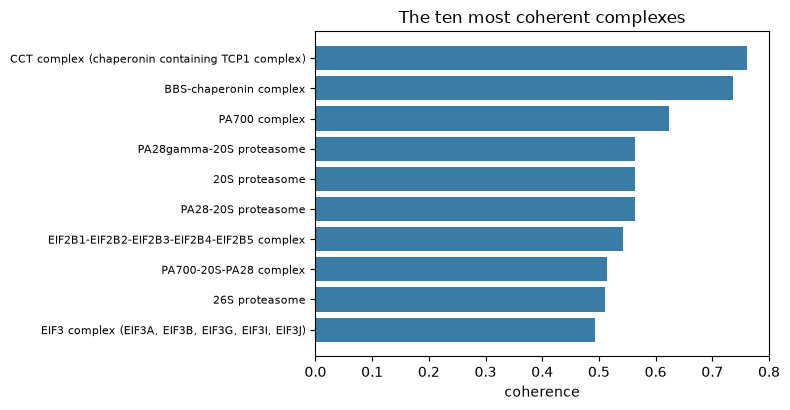

In [16]:
top = coherence.nlargest(10, "coherence").iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(range(len(top)), top["coherence"], color="#3a7ca5")
ax.set_yticks(range(len(top)), top["set"], fontsize=8)
ax.set(xlabel="coherence", title="The ten most coherent complexes")
fig.tight_layout()
plt.show()

Half of the complexes with at least five screened genes are coherent. The top of the list is machinery a
dividing cell cannot do without: the chaperonin that folds actin and tubulin, the proteasome in several of its
CORUM entries, and the translation initiation factor eIF2B. The BBS-chaperonin entry is coherent through the
chaperonin subunits it shares.

## Nearest neighbours

A gene of unknown function is annotated by the knockouts nearest to it. Four well-known genes show what that
looks like here. `*` marks a partner from one of the query's CORUM complexes, and `^` a gene on its chromosome
arm.

In [17]:
def unit_rows(profiles):
    """The profiles scaled to unit length, so a matrix product gives cosine similarities."""
    values = np.asarray(profiles.X, dtype=np.float64)
    return values / np.linalg.norm(values, axis=1, keepdims=True)


unit = unit_rows(genes)
symbols = genes.obs["Metadata_Perturbation"].astype(str).to_numpy()
arms = genes.obs["Metadata_ChromosomeArm"].astype(object).to_numpy()


def neighbours(query, k=8):
    """The k knockouts most like the query's; * shares a CORUM complex with it, ^ sits on its chromosome arm."""
    i = int(np.flatnonzero(symbols == query)[0])
    shared = complexes["source"].isin(complexes.loc[complexes["target"] == query, "source"])
    partners = set(complexes.loc[shared, "target"])
    nearest = [j for j in np.argsort(-(unit @ unit[i])) if j != i][:k]
    marks = [
        symbols[j] + ("*" if symbols[j] in partners else "") + ("^" if pd.notna(arms[i]) and arms[j] == arms[i] else "")
        for j in nearest
    ]
    return ", ".join(marks)


for query in ("PSMB2", "CCT2", "EIF3B", "POLR2A"):
    print(f"{query:7s}{neighbours(query)}")

PSMB2  PSMB3*, PSMB7*, PSMB4*, PSMB6*, PSMA4*, PSMA6*, PSMA1*, PSMA5*^
CCT2   TCP1*, CCT6A*, CCT4*, CCT3*, CCT5*, CCT7*, CCT8*, ILF2
EIF3B  EIF3I*, EIF1AX, EIF3A*, EIF2S3, EIF3G*, EIF3E*, DDX3X, EIF2S1
POLR2A EIF4A3, HSPA5, NXF1, MAT2A, POLR2G*, RAN, ACOT6, WEE1


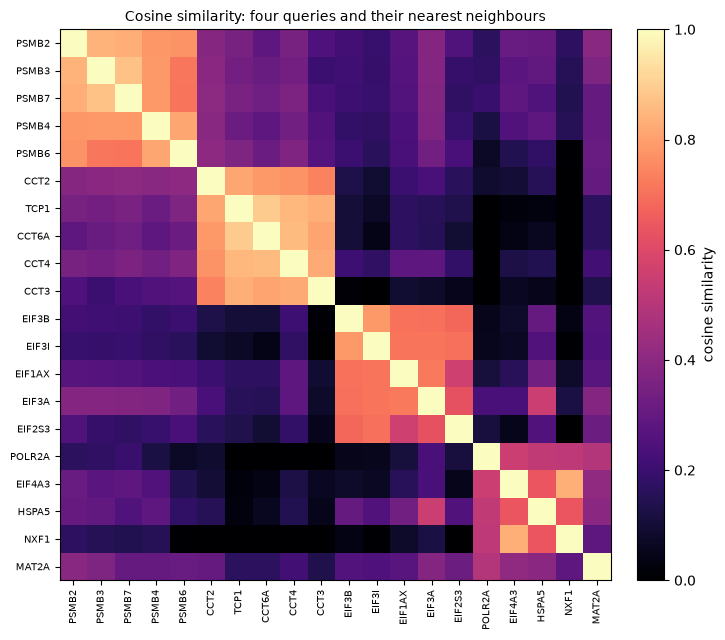

In [18]:
seeds = ["PSMB2", "CCT2", "EIF3B", "POLR2A"]
picked = []
for query in seeds:
    i = int(np.flatnonzero(symbols == query)[0])
    nearest = [j for j in np.argsort(-(unit @ unit[i])) if j != i][:4]
    for j in [i, *nearest]:
        if j not in picked:
            picked.append(j)
picked = np.array(picked)
labels = symbols[picked]
block = unit[picked] @ unit[picked].T

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(block, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels)), labels, fontsize=7)
ax.set_title("Cosine similarity: four queries and their nearest neighbours", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cosine similarity")
fig.tight_layout()
plt.show()

Three of the four read as their complexes. PSMB2's eight nearest knockouts are all proteasome subunits. CCT2's
are seven chaperonin subunits and ILF2. EIF3B's are translation initiation factors: four eIF3 subunits, eIF2,
eIF1A and the helicase DDX3X. POLR2A, the largest subunit of RNA polymerase II, finds only one polymerase subunit
among its neighbours. Several of the others, such as HSPA5 and WEE1, are genes whose knockouts leave few cells
behind, as its own does; the last section measures that.

Only one of these neighbours sits on its query's chromosome arm.

## Neighbours on the same chromosome arm

A Cas9 cut can do more than break one gene: it can truncate the chromosome arm around it. Knockouts of genes on
one arm then share a phenotype that says nothing about the genes. jump-profiling-recipe corrects for this with
the same loci that fill `Metadata_ChromosomeArm`.

In [19]:
def same_arm(profiles, k=10):
    """Share of each gene's k nearest knockouts that sit on its chromosome arm."""
    arm = profiles.obs["Metadata_ChromosomeArm"].astype(object).to_numpy()
    known = pd.notna(arm)
    arm, values = arm[known], unit_rows(profiles)[known]
    similarity = values @ values.T
    np.fill_diagonal(similarity, -np.inf)
    nearest = np.argpartition(-similarity, k, axis=1)[:, :k]
    return float((arm[nearest] == arm[:, None]).mean())


sizes = pd.Series(arms).value_counts()
n = sizes.sum()
same_arm_fractions = {
    "a random pair (chance)": float((sizes * (sizes - 1)).sum() / (n * (n - 1))),
    "10 nearest, as published": same_arm(published),
    "10 nearest, after sphering": same_arm(genes),
}

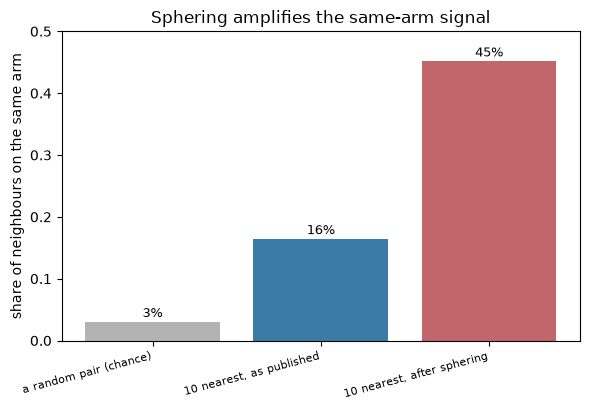

In [20]:
labels = list(same_arm_fractions)
values = [same_arm_fractions[k] for k in labels]

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(range(len(labels)), values, color=["0.7", "#3a7ca5", "#c1666b"])
for i, v in enumerate(values):
    ax.text(i, v + 0.008, f"{v:.0%}", ha="center", fontsize=9)
ax.set_xticks(range(len(labels)), labels, rotation=15, ha="right", fontsize=8)
ax.set(ylabel="share of neighbours on the same arm", ylim=(0, 0.5), title="Sphering amplifies the same-arm signal")
fig.tight_layout()
plt.show()

Two genes drawn at random share an arm 3% of the time. A gene's ten nearest knockouts share it 16% of the time
as published, more than five times chance, and 45% after sphering. Sphering scales up the directions the
controls barely vary in, and the arm signal is one of them, because no control well has a cut.

That does not undo the complexes above, whose partners were rarely on the same arm. It does make a neighbour on
the query's own arm weak evidence of a shared function, and it is the reason to correct for the arm before
reading guilt by association across the genome.

## Essential genes lose cells

A knockout of a gene the cell needs leaves fewer cells. `viability` below is each well's cell count against the
median of the negative controls on its plate, as a median per gene.

In [21]:
plate_controls = obs[obs["Metadata_Control"]].groupby("Metadata_Plate", observed=True)["Metadata_CellCount"].median()
viability = obs["Metadata_CellCount"] / obs["Metadata_Plate"].map(plate_controls).astype(float)
by_gene = viability[is_trt].groupby(treated["Metadata_Perturbation"], observed=True).median()
activity = wells.uns["mantispy"]["activity"].set_index("Metadata_Perturbation")["mean_average_precision"]
cells = pd.DataFrame({"viability": by_gene}).join(activity.rename("activity mAP")).dropna()

proteasome = complexes.loc[complexes["source"] == "26S proteasome", "target"]
print(
    {
        "median viability, every gene": round(float(cells["viability"].median()), 2),
        "median viability, 26S proteasome": round(float(cells["viability"].reindex(proteasome).median()), 2),
        "Spearman, viability against activity mAP": round(
            float(spearmanr(cells["viability"], cells["activity mAP"]).statistic), 2
        ),
    }
)
cells.nsmallest(8, "viability").round(2)

{'median viability, every gene': 0.75, 'median viability, 26S proteasome': 0.32, 'Spearman, viability against activity mAP': -0.54}


,viability,activity mAP
Metadata_Perturbation,,
POLR2A,0.19,0.85
KIF11,0.22,1.00
RRM2,0.23,0.93
WEE1,0.23,1.00
MDM2,0.24,1.00
HSPA5,0.24,1.00
CASP8AP2,0.25,1.00
RRM1,0.25,1.00


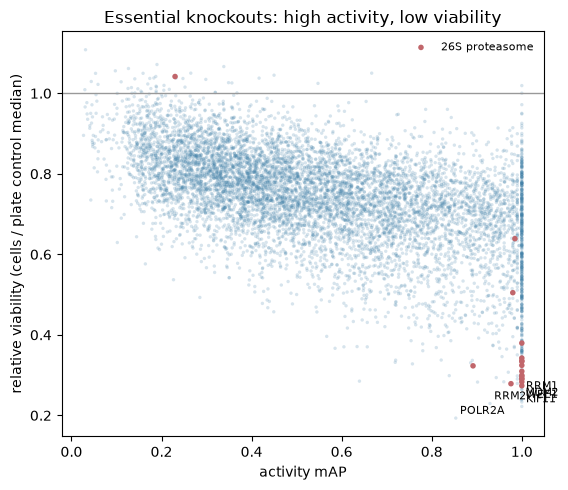

In [22]:
in_proteasome = cells.index.isin(set(proteasome))

fig, ax = plt.subplots(figsize=(5.8, 5))
ax.scatter(cells["activity mAP"], cells["viability"], s=6, alpha=0.2, color="#3a7ca5", edgecolor="none")
ax.scatter(
    cells.loc[in_proteasome, "activity mAP"],
    cells.loc[in_proteasome, "viability"],
    s=16,
    color="#c1666b",
    edgecolor="none",
    label="26S proteasome",
)
for gene in ["POLR2A", "RRM1", "RRM2", "WEE1", "KIF11", "MDM2"]:
    if gene in cells.index:
        ax.annotate(
            gene,
            (cells.loc[gene, "activity mAP"], cells.loc[gene, "viability"]),
            fontsize=8,
            xytext=(3, 3),
            textcoords="offset points",
        )
ax.axhline(1.0, color="0.6", lw=1)
ax.set(
    xlabel="activity mAP",
    ylabel="relative viability (cells / plate control median)",
    title="Essential knockouts: high activity, low viability",
)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Proteasome knockouts keep a third of the controls' cells, against three quarters for the median gene. The
knockouts that lose the most are genes a dividing cell needs: RNA polymerase II, ribonucleotide reductase (RRM1
and RRM2), the checkpoint kinase WEE1, and KIF11, the kinesin Eg5 that BBBC021's Eg5 inhibitors target. MDM2 is
among them too: without it p53 is no longer held in check, and U2OS cells carry a working p53.

Phenotype strength tracks cell loss even though the profiles were corrected for cell count: the less viable a
knockout, the higher its activity mAP, at a rank correlation of −0.54. A strong phenotype can be a dying cell,
as [Hits, effects and cell loss](../compounds/hits.ipynb) shows for compounds. Read
the neighbours of a lethal knockout as neighbours in dying, as POLR2A's were.

## Summary

- {func}`~mantispy.ds.jump_crispr` names every well's gene, its control type and its chromosome arm, and
  {func}`~mantispy.ds.corum` supplies complexes to check the map against.
- Many knockouts have a phenotype; a replicable, specific one is rarer. Report both.
- Measure chance for complex recovery with `n_permutations`. Here the shuffled annotation sits above twice the
  tail width.
- Genes of one complex phenocopy each other, which is what guilt by association rests on.
- Knockouts of neighbouring genes also look alike, because of the cut rather than the genes, and sphering
  amplifies it. Check a neighbour's chromosome arm before reading it as a shared function.
- The most lethal knockouts have some of the strongest phenotypes, and cell loss tracks phenotype strength. Read
  cell loss beside the map.